# E3.x — Extended MD Analysis · System 3 / 9 · **GGE_water** (Tier D — multi-basin)

**DES-Peptide Study — Paper 1** · pipeline-validation system · template for systems 2–9

This notebook is the **template**. The only block that changes for downstream systems is the
per-system spec (§2–§3) plus the tier-handling branches (B/C/D are no-ops here). Tier A =
clean/ergodic → equal-weight pool of all starts, standard corrected stats, no basin splits.

## Scientific spine (Paper1 workflow E3.1–E3.3) and the primitive→question crosswalk
The Paper1 extension workflow organises E3 by *question*, one per section. This notebook computes
by *primitive* (RDFs, then coordination, then H-bonds) because the RDF cutoffs are a shared
prerequisite for both backbone and side-chain coordination — so the primitives cut across the
questions. The crosswalk below is the authoritative mapping; each computational section header names
the question(s) it serves.

- **E3.1 — Replicate-aware SASA & backbone coordination** (does this system converge; is the named
  significance case resolved?). Served by: carried E2.2 SASA/Rg convergence (setup), the *backbone*
  rows of the RDF-cutoff and coordination sections.
- **E3.2 — Side-chain coordination** (is the indirect-restructuring hypothesis supported or challenged
  once side-chain contacts are included?). Served by: the *side-chain* rows of the RDF-cutoff and
  coordination sections, plus the ±0.05 nm sensitivity.
- **E3.3 — Backbone hydrogen bonds** (does the YIY reline anomaly persist and is it replicate-consistent?).
  Served by: the H-bond section.
- **E3.4 — System summary** — collates the above and, per system, states what it *closes* versus what it
  only *contributes toward* (deferred to the cross-solvent stage). Emits `{SYSTEM}_summary.csv`,
  `{SYSTEM}_summary.md` (the readable record), and `{SYSTEM}_summary_figure.png`.

Note on statistics vs the Paper1 plan: the plan's E3.1 named inter-replicate mean ± SEM (n=3) over
velocity replicates, with block-bootstrap secondary. The executed campaign replaced that design with
diverse-start sampling and the pooled ACF-corrected leave-one-out framework below; the plan's
statistical language is superseded (see the methodology reconciliation note for E5 Methods).

## Standing conventions (E2.x §5 / E3.x §9)
- **Corrected statistics are primary** and are *imported*, not reimplemented:
  `N_eff = N/τ_int`, `se = std(ddof=1)/√N_eff`, `ci95 = 1.96·se` (FFT-ACF, Sokal c=5.0, τ floored at 1).
  **This is a parametric ACF-corrected SE — not a bootstrap.**
- **Canonical series:** 20–200 ns window, `stride=10` (10 ps), 18,000 frames/start — the exact series
  E2.2 cell-7b pooled. Any statistic that must be comparable to E2.x lives on this series.
- **Findings as observations**, not conclusions. `compact/mid/extended` are start labels only; use the
  measured quantity ("lower-Rg", the value) for equilibrated results.
- **Citations:** `[REF]` placeholders only.

## Prerequisites (read before running)
1. `extension/convergence_stats.py` present (the E2.2 module).
2. **Sidecars present:** `convergence_pooled_GGE_water.csv` and `convergence_loo_GGE_water.csv`.
   The committed `convergence_summary_GGE_water.csv` is **pairwise-only** and does *not* carry pooled
   CIs. If the sidecars are absent, **run the refactored E2.2 for GGE_water first** (emits the pooled/loo sidecars). §5 halts
   with instructions if they're missing.
3. Extended DCDs present locally under `extension/trajectories_extended/` (gitignored, MacBook-only —
   E2.x backup caveat still open).

## Compute (estimate — M5 Max, CPU-bound MDTraj)
Load ~4–6 min · RDFs ~30–50 min · coordination ~10–20 min + one stride=1 point-estimate check
(~5–10 min) · H-bonds ~15–30 min incl. stride=1-vs-10 test → **~1.5–2.5 h**. The two heavy passes
(§6b, §7b) load a single start at full 1 ps resolution and are isolated as such.


## §1 — Configuration & imports

**In:** `convergence_stats.py` (E2.2 module), pinned constants.
**Out:** paths, output tree, canonical window/stride, RDF parameters.

The `SYSTEM` / `TIER` pair is the only knob that changes per system. Window and stride are pulled
from the module's pinned constants so E3.x cannot silently drift off the E2.x convention.


In [12]:
import os, re, sys, json, time
import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# ── E2.2 corrected-stats module (import; do NOT reimplement) ───────────────────
PROJECT_DIR = os.path.expanduser('~/des-peptide-study')
EXT_DIR     = os.path.join(PROJECT_DIR, 'extension')
if EXT_DIR not in sys.path:
    sys.path.insert(0, EXT_DIR)
from convergence_stats import (
    compute_stat, pooled_stability, pairwise,          # estimators
    DT_PS, STRIDE, SAVE_INTERVAL_PS, DISCARD_NS,        # pinned constants
    DEFAULT_C, TAU_FLOOR,
)
# compute_stat(series, dt_ps=10.0) -> {mean, tau_int_ns, N_eff, se, ci95}
# NOTE: pooled_stability / pairwise arg *shapes* are assumed {label: 1d-array}, [labels].
#       Reconcile against convergence_stats.py signatures on first run (see §7 wrapper).

# ── System knob (ONLY block that changes per system) ──────────────────────────
SYSTEM  = 'GGE_water'
TIER    = 'D'                      # A=clean/ergodic  B=robust-SASA/non-erg  C=one-trap  D=multi-basin
PEP, SOLVENT = SYSTEM.split('_', 1)

# ── Paths / output tree (workflow §7) ─────────────────────────────────────────
TRAJ_DIR = os.path.join(EXT_DIR, 'trajectories_extended')
SYS_DIR  = os.path.join(PROJECT_DIR, 'systems')
CONV_DIR = os.path.join(EXT_DIR, 'analysis', 'convergence')          # convergence summaries + sidecars
OUT_DIR  = os.path.join(EXT_DIR, 'analysis', 'E3x', SYSTEM)
for sub in ('rdfs', 'coordination', 'hbonds'):
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)

# ── Canonical analysis series (must match E2.2 cell-7b exactly) ───────────────
ANALYSIS_STRIDE = STRIDE                                         # 10  → 10 ps frames
DISCARD_FRAMES  = int(DISCARD_NS * 1000 / (SAVE_INTERVAL_PS * ANALYSIS_STRIDE))  # 2000
EXPECT_FRAMES   = None                                           # verified per start in §4/§8
# load stride=10 then slice [DISCARD_FRAMES:]  ==  prepare_series(raw, 20.0, 10)  ==  20–200 ns

# ── RDF parameters ────────────────────────────────────────────────────────────
RDF_RANGE          = (0.0, 1.20)    # nm — wide enough for urea-O 1st shell (~0.54) + 2nd shell
RDF_BINWIDTH       = 0.005          # nm
RDF_SMOOTH_WIN     = 11             # Savitzky–Golay window (odd) for minimum detection
G_PEAK_THRESHOLD   = 1.05           # g(r) must exceed this to count as a structured first shell
CUTOFF_SENSITIVITY = 0.05           # nm — ± band for coordination sensitivity
RDF_MAX_FIRST_MIN  = 0.60           # nm — first-shell ceiling; a detected minimum beyond this is
                                    # a second-shell/bulk feature (not coordination) -> report no shell
FIXED_BACKBONE_CUTOFF = {'water_O': 0.333}  # fallback cutoff (nm) for a backbone pair whose RDF is
                                    # too flat to cross G_PEAK_THRESHOLD but which E3.0 anchors as a real
                                    # shell (e.g. backbone-water in pure water); labelled cutoff_source='fixed'

print(f'System        : {SYSTEM}  (tier {TIER})')
print(f'Solvent       : {SOLVENT}')
print(f'Analysis series: {DISCARD_NS:.0f}–200 ns, stride={ANALYSIS_STRIDE} (dt={DT_PS:.0f} ps), '
      f'discard {DISCARD_FRAMES} strided frames')
print(f'Output tree   : {OUT_DIR}')
print(f'τ floor       : {TAU_FLOOR}  (floored τ ⇒ report as "≤1 strided lag, N_eff=N", not a measurement)')


System        : GGE_water  (tier D)
Solvent       : water
Analysis series: 20–200 ns, stride=10 (dt=10 ps), discard 2000 strided frames
Output tree   : /Users/rossgibson/des-peptide-study/extension/analysis/E3x/GGE_water
τ floor       : 1.0  (floored τ ⇒ report as "≤1 strided lag, N_eff=N", not a measurement)


## §2 — Per-system spec: index convention & motif

**Index convention (pinned).** Residue indices are positions in the **protein residue list including
the ACE cap at index 0**, identical to Phase 3's `find_motif_indices`. GGE construct `Ace-EEEGGEIVF-NMe`:

| idx | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|-----|---|---|---|---|---|---|---|---|---|---|----|
| res | ACE | E | E | E | **G** | **G** | **E** | I | V | F | NME |
| role| cap | flank | flank | flank | motif | motif | **motif Glu** | — | — | — | cap |

So **motif backbone O** = residues 4,5,6 · **motif Glu carboxyl** (headline side-chain) = residue 6 ·
**flanking EEE** (separate context series) = residues 1,2,3. These are resolved dynamically from the
topology in §8 — the integers above are the expected result, asserted, not hardcoded selectors.


## §3 — Constants & reference/partner specification

**In:** static maps.  **Out:** `SIDECHAIN_SPEC`, active `PARTNERS` for this solvent.

Side-chain references are keyed by **role** (`motif_last` = the motif's own carboxyl-bearing residue;
`nterm_acidic` = the flanking EEE stretch), resolved against discovered motif indices in §8. Partner
selection strings are **name-verified** in §8 before use (URE/CHO/CLA atom names are confirmed against
the live topology, not assumed).


In [13]:
# Amber 3→1 map incl. protonation variants + caps (caps as '+', excluded from motif search)
AA_MAP = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLU':'E','GLN':'Q','GLY':'G',
    'HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S',
    'THR':'T','TRP':'W','TYR':'Y','VAL':'V','HID':'H','HIE':'H','HIP':'H','CYX':'C',
    'ACE':'+','NME':'+',
}
MOTIF_SEQ = {'GGE':'GGE', 'CME':'CME', 'YIY':'YIY'}

# DES components present per solvent (water always implicit)
SOLVENT_COMPONENTS = {
    'water':     [],
    'reline':    ['CHO', 'CLA', 'URE'],
    'glyceline': ['CHO', 'CLA', 'GOL'],
}

# Side-chain heteroatom references per peptide (E3.x §3.1). Only GGE is exercised here;
# CME/YIY entries are placeholders completed when those systems are run.
SIDECHAIN_SPEC = {
    'GGE': {
        'motif_Glu':    dict(resname='GLU', atoms=['OE1', 'OE2'], role='motif_last'),
        'flank_Glu':    dict(resname='GLU', atoms=['OE1', 'OE2'], role='nterm_acidic'),
    },
    'CME': {   # placeholder — for system 3/7/9
        'motif_Cys':    dict(resname='CYS', atoms=['SG'],         role='motif_res', offset=0),
        'motif_Met':    dict(resname='MET', atoms=['SD'],         role='motif_res', offset=1),
        'motif_Glu':    dict(resname='GLU', atoms=['OE1','OE2'],  role='motif_res', offset=2),
    },
    'YIY': {   # placeholder — for systems 4/5/6
        'motif_Tyr':    dict(resname='TYR', atoms=['OH'],         role='motif_all_matching'),
    },
}

# Partner selections (mdtraj selection language); verified against topology in §8.
PARTNER_SELECT = {
    'water_O':   'resname HOH and name O',
    'choline_N': 'resname CHO and name N',
    'chloride':  'resname CLA',                 # monatomic; take all atoms of CLA residues
    'urea_N':    'resname URE and name N N1',    # verify names (may be N1/N2) in §8
    'urea_O':    'resname URE and name O',        # carbonyl O
    'glycerol_O':'resname GOL and name O O1 O2',  # glyceline only
}
# Map DES resnames → which partner keys they contribute
COMPONENT_PARTNERS = {
    'CHO': ['choline_N'], 'CLA': ['chloride'],
    'URE': ['urea_N', 'urea_O'], 'GOL': ['glycerol_O'],
}
PARTNERS = ['water_O']
for comp in SOLVENT_COMPONENTS[SOLVENT]:
    PARTNERS += COMPONENT_PARTNERS[comp]
# the solvent's DES carbonyl/hydroxyl-O partner (None for water); used by stride-check + figure
DES_O_PARTNER = {'reline': 'urea_O', 'glyceline': 'glycerol_O', 'water': None}[SOLVENT]

# E3.0 preliminary anchors (10 ns, backbone-O only) — validation gate for §5 backbone cutoffs
E30_ANCHOR = {
    'water_O':   (0.333, 0.343, 'well-defined; 0.35 default adequate'),
    'urea_N':    (0.358, 0.412, 'slight system dependence'),
    'urea_O':    (0.538, 0.543, 'MISSED by 0.35 default'),
    'choline_N': (None,  None,  'no structured shell'),
    'chloride':  (None,  None,  'no structured shell'),
    'glycerol_O':(None,  None,  'no structured shell (indirect-mechanism support)'),
}

print(f'Solvent {SOLVENT!r} → active partners: {PARTNERS}')
print(f'Side-chain refs for {PEP}: {list(SIDECHAIN_SPEC[PEP])}')


Solvent 'water' → active partners: ['water_O']
Side-chain refs for GGE: ['motif_Glu', 'flank_Glu']


## §4 — Discover & verify trajectory files

**In:** `trajectories_extended/`.  **Out:** `RUNS = {start: {dir, dcd}}`, topology path.

Regex `{SYSTEM}_(\d+)ns_(.+)_r(\d+)$` (E2.2 cell 4). GGE_reline is the 3-start exception →
expect **compact / mid / extended**. `r{rep}` is always `r1`. Topology at
`systems/{SYSTEM}/{SYSTEM}.prmtop` (fallback `systems/{SYSTEM}.prmtop`).


In [14]:
run_re = re.compile(rf'^{re.escape(SYSTEM)}_(\d+)ns_(.+)_r(\d+)$')

RUNS = {}
for name in sorted(os.listdir(TRAJ_DIR)):
    m = run_re.match(name)
    if not m:
        continue
    ns, start, rep = m.group(1), m.group(2), m.group(3)
    dcd = os.path.join(TRAJ_DIR, name, name + '.dcd')
    RUNS[start] = dict(dir=os.path.join(TRAJ_DIR, name), dcd=dcd, ns=int(ns), rep=rep,
                       exists=os.path.exists(dcd))

# Topology
cand = [os.path.join(SYS_DIR, SYSTEM, f'{SYSTEM}.prmtop'),
        os.path.join(SYS_DIR, f'{SYSTEM}.prmtop')]
TOP_PATH = next((p for p in cand if os.path.exists(p)), None)

print(f'{"start":<12}{"exists":<8}{"ns":<6}{"rep":<5}size(MB)')
print('-' * 40)
for s, r in RUNS.items():
    mb = os.path.getsize(r['dcd']) / 1e6 if r['exists'] else 0
    print(f'{s:<12}{str(r["exists"]):<8}{r["ns"]:<6}{r["rep"]:<5}{mb:>8.1f}')

START_LABELS = [s for s, r in RUNS.items() if r['exists']]
assert TOP_PATH, f'Topology not found in {cand}'
assert START_LABELS, 'No trajectories discovered — check TRAJ_DIR'
print(f'\nTopology: {TOP_PATH}')
print(f'Starts found ({len(START_LABELS)}): {START_LABELS}')
print(f'✓ {len(START_LABELS)}-start system: {sorted(START_LABELS)}')


start       exists  ns    rep  size(MB)
----------------------------------------
compact     True    200   1      6827.2
extended    True    200   1      6827.2
mid         True    200   1      6827.2
open        True    200   1      6827.2

Topology: /Users/rossgibson/des-peptide-study/systems/GGE_water/GGE_water.prmtop
Starts found (4): ['compact', 'extended', 'mid', 'open']
✓ 4-start system: ['compact', 'extended', 'mid', 'open']


## §5 — Carry forward E2.x convergence references

**In:** committed pairwise CSV + pooled/loo sidecars.  **Out:** carried pooled SASA/Rg ± CI, verdicts.

E3.x **consumes**; it does not recompute the convergence stats (that is E2.2's role). The committed
`convergence_summary_{SYSTEM}.csv` is pairwise-only. The pooled reference lives in the sidecars, which
exist **only after the refactored E2.2 has been rerun for this system**. If they're absent this cell
halts with instructions — that is the intended sequencing, not a failure to work around.


In [15]:
pairwise_csv = os.path.join(CONV_DIR, f'convergence_summary_{SYSTEM}.csv')
pooled_csv   = os.path.join(CONV_DIR, f'convergence_pooled_{SYSTEM}.csv')
loo_csv      = os.path.join(CONV_DIR, f'convergence_loo_{SYSTEM}.csv')

conv = {}
# Pairwise table (committed): pair, observable, delta_mean, z, overlap
if os.path.exists(pairwise_csv):
    conv['pairwise'] = pd.read_csv(pairwise_csv)
    print('Pairwise (committed):')
    print(conv['pairwise'].to_string(index=False))
else:
    print(f'⚠ pairwise summary not found: {pairwise_csv}')

# Sidecars (present only after refactored E2.2 rerun)
missing = [p for p in (pooled_csv, loo_csv) if not os.path.exists(p)]
if missing:
    print('\n' + '=' * 78)
    print('PREREQUISITE NOT MET — pooled reference is not on disk.')
    print('The committed summary is pairwise-only; pooled SASA/Rg ± CI live in sidecars.')
    print('ACTION: run the refactored E2.2 for GGE_reline to emit:')
    for p in missing:
        print(f'   - {p}')
    print('That run also executes the cell-10 regression check (early-session provenance).')
    print('§8 summary will carry NaN for pooled SASA/Rg until these exist.')
    print('=' * 78)
    conv['pooled'] = None
    conv['loo'] = None
else:
    conv['pooled'] = pd.read_csv(pooled_csv)   # observable,n_starts,pooled_mean,N_eff_pooled,ci95
    conv['loo']    = pd.read_csv(loo_csv)       # observable,dropped,mean_without,shift,shift_gt_ci
    print('\nPooled reference (sidecar):')
    print(conv['pooled'].to_string(index=False))

# Tier-A carried verdict (from E2.x foundation): both observables robust / clean-ergodic
CARRIED_VERDICT = dict(SASA='dominated', Rg='dominated', character='multi-basin (2+2 SASA split)')
print(f'\nCarried verdict: {CARRIED_VERDICT}')


Pairwise (committed):
               pair observable  delta_mean     z  overlap
compact vs extended         RG     -0.0641  2.29     0.69
compact vs extended       SASA     -0.4060  3.42     0.54
     compact vs mid         RG      0.0114  0.51     0.84
     compact vs mid       SASA      0.0934  0.82     0.87
    compact vs open         RG     -0.1123  4.33     0.54
    compact vs open       SASA     -0.5179  4.64     0.44
    extended vs mid         RG      0.0755  3.58     0.64
    extended vs mid       SASA      0.4993  7.07     0.43
   extended vs open         RG     -0.0482  1.95     0.77
   extended vs open       SASA     -0.1119  1.70     0.84
        mid vs open         RG     -0.1237  6.77     0.46
        mid vs open       SASA     -0.6112 10.53     0.32

Pooled reference (sidecar):
observable  n_starts  pooled_mean  N_eff_pooled   ci95
        RG         4        0.704         119.2 0.0176
      SASA         4        2.590         156.7 0.0656

Carried verdict: {'SASA': 'do

## §6 — Helper functions

**In:** none.  **Out:** atom-selection, RDF, first-minimum, coordination, corrected-stat helpers.

Carried verbatim from Phase 3: `get_protein_residues`, `find_motif_indices`, `compute_coordination`,
`compute_hbond_lifetimes`. New for E3.x: reference/partner resolution, pooled RDF, first-minimum
detection, and thin wrappers around the imported estimators.


In [16]:
# ── carried from Phase 3 ──────────────────────────────────────────────────────
def get_protein_residues(top):
    return [r for r in top.residues if r.name in AA_MAP]

def get_protein_sequence(top):
    return ''.join(AA_MAP.get(r.name, '?') for r in get_protein_residues(top))

def find_motif_indices(top, motif_seq):
    """Protein-residue-list indices (ACE cap = 0) of the motif."""
    seq = get_protein_sequence(top).replace('+', '')
    pos = seq.find(motif_seq)
    if pos == -1:
        raise ValueError(f'Motif {motif_seq} not in {seq}')
    prot = get_protein_residues(top)
    nc, out = 0, []
    for i, r in enumerate(prot):
        if r.name not in ('ACE', 'NME'):
            if pos <= nc < pos + len(motif_seq):
                out.append(i)
            nc += 1
    return out

def compute_coordination(traj, target_atoms, probe_atoms, cutoff, chunk_size=200):
    """{target_atom_idx: per-frame count of probe atoms within cutoff}."""
    out = {}
    if len(probe_atoms) == 0:
        return {a: np.zeros(traj.n_frames, int) for a in target_atoms}
    for a in target_atoms:
        pairs = np.array([[a, p] for p in probe_atoms], dtype=np.int32)
        counts = []
        for s in range(0, traj.n_frames, chunk_size):
            d = md.compute_distances(traj[s:s + chunk_size], pairs)
            counts.extend((d < cutoff).sum(axis=1).tolist())
        out[a] = np.asarray(counts)
    return out

def compute_hbond_lifetimes(traj, region_res_idx, prot_res, save_interval_ps, dist_cut=0.35):
    top = traj.topology
    region = {a.index for r in prot_res if r.index in region_res_idx for a in r.atoms}
    if not region:
        return [], []
    bb = [(d, h, a) for (d, h, a) in md.baker_hubbard(traj, periodic=False)
          if d in region and a in region]
    lifetimes, labels = [], []
    for (d, h, a) in bb:
        contact = md.compute_distances(traj, np.array([[d, a]]))[:, 0] < dist_cut
        runs, c = [], 0
        for v in contact:
            if v: c += 1
            elif c: runs.append(c); c = 0
        if c: runs.append(c)
        if runs:
            lifetimes.extend((np.array(runs) * save_interval_ps).tolist())
            dr, ar = top.atom(d).residue, top.atom(a).residue
            labels.append(f'{dr.name}{dr.resSeq}:{top.atom(d).name}-{ar.name}{ar.resSeq}:{top.atom(a).name}')
    return lifetimes, labels

# ── new for E3.x ──────────────────────────────────────────────────────────────
def resolve_reference_atoms(top, motif_idx):
    """Return {'backbone_O': idx-array, <sidechain-key>: idx-array, ...} for this peptide."""
    refs = {}
    # backbone O of the motif residues
    refs['backbone_O'] = np.array(
        [a.index for r in top.residues if r.index in set(motif_idx)
         for a in r.atoms if a.name == 'O'])
    prot = get_protein_residues(top)
    for key, spec in SIDECHAIN_SPEC[PEP].items():
        rn, names, role = spec['resname'], set(spec['atoms']), spec['role']
        if role == 'motif_last':                     # the motif's carboxyl-bearing residue (GGE Glu)
            target = [motif_idx[-1]]
        elif role == 'nterm_acidic':                 # flanking acidic residues before the motif
            target = [r.index for r in prot
                      if r.name == rn and r.index < motif_idx[0] and r.name != 'ACE']
        elif role == 'motif_res':                    # CME: specific motif offset
            target = [motif_idx[spec.get('offset', 0)]]
        elif role == 'motif_all_matching':           # YIY: all matching residues in motif
            target = [i for i in motif_idx if top.residue(i).name == rn]
        else:
            target = []
        idx = np.array([a.index for r in top.residues if r.index in set(target)
                        for a in r.atoms if a.name in names])
        refs[key] = idx
    return refs

def resolve_partner_atoms(top):
    """{partner_key: idx-array} for active partners; verifies non-empty + prints sample names."""
    out, report = {}, []
    for key in PARTNERS:
        idx = top.select(PARTNER_SELECT[key])
        out[key] = idx
        names = sorted({top.atom(i).name for i in idx[:50]})
        report.append((key, len(idx), names))
    return out, report

def compute_rdf_pooled(pooled_traj, ref_idx, partner_idx):
    """md.compute_rdf over the full refxpartner pair set (frames already pooled). Returns (r, g)."""
    if len(ref_idx) == 0 or len(partner_idx) == 0:
        return None, None
    pairs = np.array(np.meshgrid(ref_idx, partner_idx)).T.reshape(-1, 2)
    r, g = md.compute_rdf(pooled_traj, pairs, r_range=RDF_RANGE, bin_width=RDF_BINWIDTH)
    return r, g

def first_minimum(r, g, smooth_win=RDF_SMOOTH_WIN, g_thresh=G_PEAK_THRESHOLD,
                  max_first_min=RDF_MAX_FIRST_MIN):
    """First RDF minimum after the first structured peak, within max_first_min (nm).
    A minimum beyond max_first_min is a second-shell/bulk feature, not a first coordination
    shell -> report no shell (guards against the detector locking onto bulk for
    non-coordinating partners, e.g. glycerol-O -> backbone-O ~0.78 nm).
    Returns (r_min|None, g_smoothed)."""
    if g is None:
        return None, None
    w = min(smooth_win, (len(g) // 2) * 2 - 1) if len(g) > smooth_win else 5
    gs = savgol_filter(g, w, 3) if len(g) > 5 else g
    peak = None
    for i in range(1, len(gs) - 1):
        if gs[i] > g_thresh and gs[i] >= gs[i - 1] and gs[i] > gs[i + 1]:
            peak = i; break
    if peak is None:
        return None, gs                              # no structured shell
    for j in range(peak + 1, len(gs) - 1):
        if gs[j] <= gs[j - 1] and gs[j] < gs[j + 1]:
            rj = float(r[j])
            return (rj, gs) if rj <= max_first_min else (None, gs)  # cap: bulk minimum -> no shell
    return None, gs

# ── corrected-stat wrappers (imported estimator; NOT a bootstrap) ─────────────
def stat1(series):
    """Per-start ACF-corrected stat on the canonical series."""
    s = compute_stat(np.asarray(series, float), dt_ps=DT_PS)
    s['tau_floored'] = bool(s['tau_int_ns'] <= (TAU_FLOOR * DT_PS / 1000.0) + 1e-9)
    return s

def pooled_corrected(series_by_start, obs='coord'):
    """Pooled ACF-corrected mean ± CI across starts, via the E2.2 estimator.
    pooled_stability(data, runs, observables) expects, per label, the raw series AND
    the compute_stat result nested under 'stat' (it sums per-start N_eff):
        data[lab] = {obs: series, 'stat': {obs: compute_stat(series)}}
    Returns {pooled_mean, ci95, N_eff_pooled} for the single observable `obs`.
    Column names (observable/pooled_mean/ci95/N_eff_pooled) are the documented
    convergence_pooled_{SYSTEM}.csv sidecar schema."""
    runs = list(series_by_start)
    data = {lab: {obs: np.asarray(v, float),
                  'stat': {obs: compute_stat(np.asarray(v, float), dt_ps=DT_PS)}}
            for lab, v in series_by_start.items()}
    result = pooled_stability(data, runs, [obs])
    pool = result[0] if isinstance(result, tuple) else result   # (pool, loo) or pool
    pool_df = pool if isinstance(pool, pd.DataFrame) else pd.DataFrame(pool)
    if 'observable' in pool_df.columns:
        sel = pool_df[pool_df['observable'] == obs]
        row = sel.iloc[0] if len(sel) else pool_df.iloc[0]
    else:
        row = pool_df.iloc[0]
    return dict(pooled_mean=float(row['pooled_mean']),
                ci95=float(row['ci95']),
                N_eff_pooled=float(row['N_eff_pooled']))

print('Helpers defined.')


Helpers defined.


## §7 — Load canonical series & resolve atoms (Tier A pool)

**In:** discovered starts, topology.  **Out:** per-start strided trajs, pooled traj, atom index sets.

Load each start `stride=10`, slice `[2000:]` → 20–200 ns, 18,000 frames/start; `md.join` → pooled
(≈54,000 frames for the 3-start system). **Verification gate:** confirm the resolved motif indices are
[4,5,6], and that every partner selection is non-empty with the expected atom names, *before*
proceeding. This is the point to correct URE/CHO/CLA atom names if the topology disagrees with §3.


In [17]:
t0 = time.time()
start_trajs = {}
for s in START_LABELS:
    tr = md.load(RUNS[s]['dcd'], top=TOP_PATH, stride=ANALYSIS_STRIDE)[DISCARD_FRAMES:]
    start_trajs[s] = tr
    print(f'  {s:<10} {tr.n_frames} frames  {tr.time[0]/1000:.1f}-{tr.time[-1]/1000:.1f} ns  '
          f'box={"yes" if tr.unitcell_lengths is not None else "NO"}')
EXPECT_FRAMES = start_trajs[START_LABELS[0]].n_frames
assert all(t.unitcell_lengths is not None for t in start_trajs.values()), 'RDF needs unit cell info'

pooled_traj = md.join([start_trajs[s] for s in START_LABELS])
print(f'Pooled: {pooled_traj.n_frames} frames  ({len(START_LABELS)} starts)  '
      f'load {time.time()-t0:.0f}s')

top = pooled_traj.topology
prot_res = get_protein_residues(top)
motif_idx = find_motif_indices(top, MOTIF_SEQ[PEP])
print(f'\nPeptide: {get_protein_sequence(top)}  |  motif {MOTIF_SEQ[PEP]} at idx {motif_idx}')
for i in motif_idx:
    print(f'   [{i}] {top.residue(i).name}{top.residue(i).resSeq}')
if PEP == 'GGE':
    assert motif_idx == [4, 5, 6], f'index-convention check failed: {motif_idx}'

REF = resolve_reference_atoms(top, motif_idx)
PART, part_report = resolve_partner_atoms(top)
print('\nReference atom sets:')
for k, v in REF.items():
    print(f'   {k:<14} n={len(v):<3} {[top.atom(i).name for i in v[:6]]}'
          f'{" residues="+str(sorted({top.atom(i).residue.resSeq for i in v})) if len(v) else ""}')
print('\nPartner atom sets (VERIFY names before proceeding):')
for key, n, names in part_report:
    flag = '  ⚠ EMPTY' if n == 0 else ''
    print(f'   {key:<12} n={n:<5} names={names}{flag}')
assert all(len(PART[k]) > 0 for k in PARTNERS), 'a partner selection is empty — fix atom names in §3'


  compact    18000 frames  20.0-200.0 ns  box=yes
  extended   18000 frames  20.0-200.0 ns  box=yes
  mid        18000 frames  20.0-200.0 ns  box=yes
  open       18000 frames  20.0-200.0 ns  box=yes
Pooled: 72000 frames  (4 starts)  load 1s

Peptide: +EEEGGEIVF+  |  motif GGE at idx [4, 5, 6]
   [4] GLY4
   [5] GLY5
   [6] GLU6

Reference atom sets:
   backbone_O     n=3   ['O', 'O', 'O'] residues=[4, 5, 6]
   motif_Glu      n=2   ['OE1', 'OE2'] residues=[6]
   flank_Glu      n=6   ['OE1', 'OE2', 'OE1', 'OE2', 'OE1', 'OE2'] residues=[1, 2, 3]

Partner atom sets (VERIFY names before proceeding):
   water_O      n=899   names=['O']


## §7b · E3.1 (tier D only) — basin-split SASA

**Runs only when `TIER == 'D'`** (multi-basin systems: GGE_water, CME_glyceline). For these the
pooled SASA is a diverse-start ensemble over non-interconverting basins, **not an equilibrium mean**.

**In:** per-start trajectories, motif residues.  **Out:** `{SYSTEM}_basin_sasa.csv`, `basin_sasa` dict.

Recomputes per-start motif SASA on the canonical 20–200 ns window (Shrake–Rupley on the protein
slice), cross-checks the pooled value against the E2.2 sidecar (validation gate: the SASA definition
must match E2.x), classifies the 2+2 basins around the pooled boundary, and reports grouped-start
basin means with corrected CIs (option a). Coordination and H-bonds remain pooled across all starts —
they are local and basin-independent. Compute: Shrake–Rupley over 4×18k frames, ~2–4 min.


In [18]:
basin_sasa = None
if TIER == 'D':
    prot_res_idx = [r.index for r in get_protein_residues(top)]
    prot_sel = top.select('resid ' + ' '.join(map(str, prot_res_idx)))
    motif_pos = [prot_res_idx.index(m) for m in motif_idx]     # motif position in the protein slice

    sasa_by_start = {}
    for s in START_LABELS:
        trp = start_trajs[s].atom_slice(prot_sel)
        sres = md.shrake_rupley(trp, mode='residue')            # nm^2, (nframes, n_prot_res)
        sasa_by_start[s] = sres[:, motif_pos].sum(axis=1).astype(float)

    per = {s: stat1(sasa_by_start[s]) for s in START_LABELS}
    pooled_chk = pooled_corrected(sasa_by_start, obs='sasa')
    sidecar = (float(conv['pooled'][conv['pooled']['observable'].str.upper() == 'SASA']['pooled_mean'].iloc[0])
               if conv.get('pooled') is not None else np.nan)
    dpool = abs(pooled_chk['pooled_mean'] - sidecar)
    print(f'motif SASA pooled (E3.x recompute): {pooled_chk["pooled_mean"]:.4f} +/- {pooled_chk["ci95"]:.4f} nm2')
    print(f'E2.2 sidecar SASA                 : {sidecar:.4f} nm2   (delta={dpool:.4f})')
    if dpool > 0.05:
        print('   WARNING delta>0.05: SASA definition may differ from E2.2 — reconcile before trusting the split')

    boundary = pooled_chk['pooled_mean']
    highs = [s for s in START_LABELS if per[s]['mean'] > boundary]
    lows  = [s for s in START_LABELS if per[s]['mean'] <= boundary]
    hi = pooled_corrected({s: sasa_by_start[s] for s in highs}, obs='sasa') if highs else None
    lo = pooled_corrected({s: sasa_by_start[s] for s in lows},  obs='sasa') if lows  else None

    print('\nPer-start motif SASA (nm2), boundary = pooled mean:')
    for s in START_LABELS:
        print(f'   {s:<10} {per[s]["mean"]:.4f} +/- {per[s]["ci95"]:.4f}  (N_eff {per[s]["N_eff"]:.0f})  '
              f'-> {"HIGH" if s in highs else "LOW"}')
    print(f'\nGrouped-start basin means (corrected CIs):')
    print(f'   HIGH ({", ".join(highs)}): {hi["pooled_mean"]:.4f} +/- {hi["ci95"]:.4f} nm2' if hi else '   HIGH: (none)')
    print(f'   LOW  ({", ".join(lows)}): {lo["pooled_mean"]:.4f} +/- {lo["ci95"]:.4f} nm2' if lo else '   LOW: (none)')
    print('   CAVEAT: diverse-start ensemble; basin populations are NOT equilibrium (enhanced sampling -> Paper 2).')

    basin_sasa = dict(
        boundary=round(boundary, 4), sidecar_sasa=round(sidecar, 4), sidecar_delta=round(dpool, 4),
        pooled_mean=round(pooled_chk['pooled_mean'], 4), pooled_ci95=round(pooled_chk['ci95'], 4),
        high_starts=';'.join(highs), low_starts=';'.join(lows),
        high_mean=(round(hi['pooled_mean'], 4) if hi else np.nan), high_ci95=(round(hi['ci95'], 4) if hi else np.nan),
        low_mean=(round(lo['pooled_mean'], 4) if lo else np.nan),  low_ci95=(round(lo['ci95'], 4) if lo else np.nan),
        per_start=';'.join(f'{s}:{per[s]["mean"]:.4f}' for s in START_LABELS))
    pd.DataFrame([basin_sasa]).to_csv(os.path.join(OUT_DIR, f'{SYSTEM}_basin_sasa.csv'), index=False)
else:
    print(f'Tier {TIER}: not multi-basin; SASA carried from E2.2 sidecar (no basin split).')


motif SASA pooled (E3.x recompute): 2.5900 +/- 0.0656 nm2
E2.2 sidecar SASA                 : 2.5900 nm2   (delta=0.0000)

Per-start motif SASA (nm2), boundary = pooled mean:
   compact    2.3824 +/- 0.2064  (N_eff 14)  -> LOW
   extended   2.7884 +/- 0.1070  (N_eff 32)  -> HIGH
   mid        2.2891 +/- 0.0880  (N_eff 51)  -> LOW
   open       2.9003 +/- 0.0721  (N_eff 60)  -> HIGH

Grouped-start basin means (corrected CIs):
   HIGH (extended, open): 2.8443 +/- 0.0617 nm2
   LOW  (compact, mid): 2.3357 +/- 0.0882 nm2
   CAVEAT: diverse-start ensemble; basin populations are NOT equilibrium (enhanced sampling -> Paper 2).


## §8 · E3.1 + E3.2 — RDF cutoff derivation (backbone shells → E3.1, side-chain shells → E3.2)

**In:** pooled traj, atom sets.  **Out:** `rdfs/rdf_cutoffs.csv`, RDF figures.

Pooled RDF for every (reference set) x (active partner). First-minimum → cutoff. Backbone-O cutoffs
are cross-checked against the E3.0 10 ns anchors as a sanity gate; **side-chain cutoffs are novel**
(no E3.0 precedent) and carry the low-reference-atom-count caveat (workflow open-Q3).


In [19]:
REF_SETS = ['backbone_O'] + [k for k in SIDECHAIN_SPEC[PEP]]
rdf_curves, cutoff_rows = {}, []

for ref_key in REF_SETS:
    ref_idx = REF[ref_key]
    if len(ref_idx) == 0:
        print(f'{ref_key}: no reference atoms, skipping'); continue
    for pk in PARTNERS:
        r, g = compute_rdf_pooled(pooled_traj, ref_idx, PART[pk])
        rmin, gs = first_minimum(r, g)
        rdf_curves[(ref_key, pk)] = (r, g, gs, rmin)
        cutoff_val = rmin
        cutoff_source = 'rdf' if rmin is not None else 'none'
        note = ''
        if ref_key == 'backbone_O' and pk in E30_ANCHOR:
            lo, hi, desc = E30_ANCHOR[pk]
            if rmin is None:
                # flat RDF: fixed-cutoff fallback ONLY where E3.0 anchors a real shell
                if lo is not None and pk in FIXED_BACKBONE_CUTOFF:
                    cutoff_val = FIXED_BACKBONE_CUTOFF[pk]
                    cutoff_source = 'fixed'
                    note = (f'flat RDF (g_max<{G_PEAK_THRESHOLD}); fixed cutoff {cutoff_val:.3f} '
                            f'(E3.0 {lo:.3f}-{hi:.3f}) - baseline, not RDF-derived')
                else:
                    note = f'no shell (E3.0: {desc})'
            elif lo is not None:
                inside = lo - 0.03 <= rmin <= hi + 0.03
                note = f'E3.0 {lo:.3f}-{hi:.3f} -> {"ok" if inside else "off-anchor"}'
            else:
                note = f'shell at {rmin:.3f} but E3.0 expected none'
        cutoff_rows.append(dict(reference=ref_key, partner=pk,
                                first_min_nm=(round(cutoff_val, 3) if cutoff_val is not None else np.nan),
                                cutoff_source=cutoff_source,
                                n_ref=len(ref_idx), n_partner=len(PART[pk]),
                                sidechain_novel=(ref_key != 'backbone_O'), note=note))

cutoffs_df = pd.DataFrame(cutoff_rows)
cutoffs_df.to_csv(os.path.join(OUT_DIR, 'rdfs', 'rdf_cutoffs.csv'), index=False)
print(cutoffs_df.to_string(index=False))

# cutoff lookup for §9/§10
CUTOFF = {(row.reference, row.partner): row.first_min_nm
          for row in cutoffs_df.itertuples() if not np.isnan(row.first_min_nm)}


 reference partner  first_min_nm cutoff_source  n_ref  n_partner  sidechain_novel                                                                                     note
backbone_O water_O         0.333         fixed      3        899            False flat RDF (g_max<1.05); fixed cutoff 0.333 (E3.0 0.333-0.343) - baseline, not RDF-derived
 motif_Glu water_O         0.322           rdf      2        899             True                                                                                         
 flank_Glu water_O         0.322           rdf      6        899             True                                                                                         


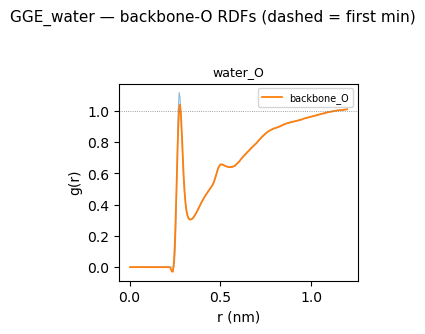

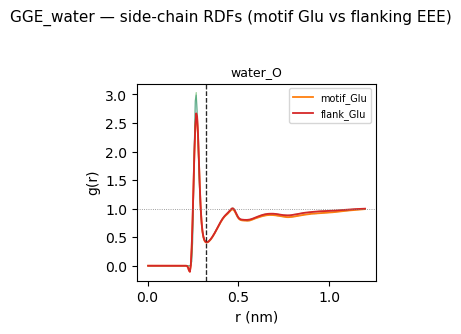

In [20]:
# RDF figures: backbone-O panel + side-chain panel
def rdf_panel(ref_keys, fname, title):
    n = len(PARTNERS)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), sharey=False)
    axes = np.atleast_1d(axes)
    for j, pk in enumerate(PARTNERS):
        ax = axes[j]
        for ref_key in ref_keys:
            if (ref_key, pk) not in rdf_curves: continue
            r, g, gs, rmin = rdf_curves[(ref_key, pk)]
            if g is None: continue
            ax.plot(r, g, lw=0.8, alpha=0.5)
            ax.plot(r, gs, lw=1.3, label=ref_key)
            if rmin: ax.axvline(rmin, ls='--', lw=0.9, color='k', alpha=0.6)
        ax.axhline(1.0, ls=':', lw=0.6, color='grey')
        ax.set_title(pk, fontsize=9); ax.set_xlabel('r (nm)')
        if j == 0: ax.set_ylabel('g(r)')
        ax.legend(fontsize=7)
    fig.suptitle(title, y=1.03, fontsize=11); fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'rdfs', fname), dpi=200, bbox_inches='tight')
    plt.show()

rdf_panel(['backbone_O'], 'backbone_O_rdfs.png', f'{SYSTEM} — backbone-O RDFs (dashed = first min)')
rdf_panel([k for k in SIDECHAIN_SPEC[PEP]], 'sidechain_rdfs.png',
          f'{SYSTEM} — side-chain RDFs (motif Glu vs flanking EEE)')


## §9 · E3.1 + E3.2 — Coordination numbers (backbone → E3.1, side-chain → E3.2; load-bearing)

**In:** cutoffs, per-start trajs.  **Out:** `coordination/backbone_coordination.csv`,
`coordination/sidechain_coordination.csv`.

Per (reference set x partner): per-start per-frame **total contacts** to the reference set at the
pair-specific cutoff → ACF-corrected per-start stat + pooled mean ± CI (summed N_eff). Also a
per-reference-atom-normalised column for cross-motif comparison. Pairs with **no structured shell**
(no cutoff) are reported as "no coordination" — the direct test of the indirect-mechanism hypothesis.


In [21]:
def coordination_table(ref_keys):
    rows = []
    for ref_key in ref_keys:
        ref_idx = REF[ref_key]
        if len(ref_idx) == 0: continue
        for pk in PARTNERS:
            cut = CUTOFF.get((ref_key, pk))
            if cut is None:
                rows.append(dict(reference=ref_key, partner=pk, cutoff_nm=np.nan,
                                 pooled_coord=0.0, ci95=0.0, N_eff_pooled=np.nan,
                                 per_atom=0.0, structured_shell=False, note='no shell → no coordination'))
                continue
            series_by_start, per_start_rows = {}, []
            for s in START_LABELS:
                per = compute_coordination(start_trajs[s], list(ref_idx), PART[pk], cutoff=cut)
                total = np.sum([per[a] for a in ref_idx], axis=0).astype(float)
                series_by_start[s] = total
                st = stat1(total)
                per_start_rows.append((s, st['mean'], st['ci95'], st['N_eff'], st['tau_floored']))
            pooled = pooled_corrected(series_by_start)
            pm  = pooled.get('pooled_mean');  ci = pooled.get('ci95');  ne = pooled.get('N_eff_pooled')
            rows.append(dict(reference=ref_key, partner=pk, cutoff_nm=round(cut, 3),
                             pooled_coord=round(float(pm), 4), ci95=round(float(ci), 4),
                             N_eff_pooled=(round(float(ne), 1) if ne is not None else np.nan),
                             per_atom=round(float(pm) / len(ref_idx), 4),
                             structured_shell=True,
                             note=';'.join(f'{s}:{m:.3f}±{c:.3f}(Neff{ne_:.0f}{"*" if tf else ""})'
                                           for s, m, c, ne_, tf in per_start_rows)))
    return pd.DataFrame(rows)

bb_coord = coordination_table(['backbone_O'])
sc_coord = coordination_table([k for k in SIDECHAIN_SPEC[PEP]])
bb_coord.to_csv(os.path.join(OUT_DIR, 'coordination', 'backbone_coordination.csv'), index=False)
sc_coord.to_csv(os.path.join(OUT_DIR, 'coordination', 'sidechain_coordination.csv'), index=False)
print('BACKBONE-O coordination:'); print(bb_coord.drop(columns='note').to_string(index=False))
print('\nSIDE-CHAIN coordination:'); print(sc_coord.drop(columns='note').to_string(index=False))
print('\n(* on a per-start Neff = floored τ ⇒ N_eff=N, not a resolved correlation time)')


BACKBONE-O coordination:
 reference partner  cutoff_nm  pooled_coord  ci95  N_eff_pooled  per_atom  structured_shell
backbone_O water_O      0.333        4.8929 0.255         197.1     1.631              True

SIDE-CHAIN coordination:
reference partner  cutoff_nm  pooled_coord   ci95  N_eff_pooled  per_atom  structured_shell
motif_Glu water_O      0.322        6.3564 0.0201        9390.2    3.1782              True
flank_Glu water_O      0.322       19.3362 0.0215       22955.7    3.2227              True

(* on a per-start Neff = floored τ ⇒ N_eff=N, not a resolved correlation time)


In [22]:
# Cutoff sensitivity: pooled coordination at cutoff ± 0.05 nm (workflow §3.1)
# ONE distance pass per (reference, partner, start); the three cutoffs are applied as
# thresholds on the same distances. (The naive version recomputed distances 3x —
# water-dominated and ~3x slower; it matters because tier C/D run this cell twice.)
def coord_series_multicut(traj, ref_idx, partner_idx, cutoffs, chunk_size=200):
    """Per-frame TOTAL contacts to the reference set at several cutoffs, one distance
    pass. Total contacts = count of all (ref x partner) pairs under cutoff, so a single
    flattened pair set suffices. Returns {cutoff: 1d array over frames}."""
    pairs = np.array(np.meshgrid(np.asarray(ref_idx), np.asarray(partner_idx))
                     ).T.reshape(-1, 2).astype(np.int32)
    acc = {c: [] for c in cutoffs}
    for s in range(0, traj.n_frames, chunk_size):
        d = md.compute_distances(traj[s:s + chunk_size], pairs)
        for c in cutoffs:
            acc[c].extend((d < c).sum(axis=1).tolist())
    return {c: np.asarray(v, float) for c, v in acc.items()}

sens_rows = []
for ref_key in ['backbone_O'] + [k for k in SIDECHAIN_SPEC[PEP]]:
    ref_idx = REF[ref_key]
    if len(ref_idx) == 0: continue
    for pk in PARTNERS:
        cut = CUTOFF.get((ref_key, pk))
        if cut is None: continue
        cuts = (round(cut - CUTOFF_SENSITIVITY, 4), cut, round(cut + CUTOFF_SENSITIVITY, 4))
        per_start = {s: coord_series_multicut(start_trajs[s], ref_idx, PART[pk], cuts)
                     for s in START_LABELS}
        vals = {}
        for c, tag in zip(cuts, ('lo', 'mid', 'hi')):
            sbs = {s: per_start[s][c] for s in START_LABELS}
            vals[tag] = float(pooled_corrected(sbs).get('pooled_mean'))
        rel = abs(vals['hi'] - vals['lo']) / vals['mid'] if vals['mid'] else np.nan
        # rel_spread is a magnitude-SENSITIVITY coefficient, not a pass/fail: a coordination
        # integral is steep through a dense first shell, so a ±0.05 nm shift moves the count
        # substantially for ANY real shell. Grade the magnitude; report the qualitative
        # robustness that actually holds (shell present across the band).
        shell_across_band = bool((vals['lo'] > 0) and (vals['mid'] > 0) and (vals['hi'] > 0))
        mag = ('n/a' if rel != rel else 'low' if rel < 0.15 else 'moderate' if rel < 0.50 else 'high')
        sens_rows.append(dict(reference=ref_key, partner=pk, cutoff_nm=round(cut, 3),
                              coord_lo=round(vals['lo'], 3), coord_mid=round(vals['mid'], 3),
                              coord_hi=round(vals['hi'], 3), rel_spread=round(rel, 3),
                              mag_sensitivity=mag, shell_across_band=shell_across_band))
sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv(os.path.join(OUT_DIR, 'rdfs', 'rdf_sensitivity.csv'), index=False)
print(sens_df.to_string(index=False))
print('\nrel_spread = |coord(cut+0.05)-coord(cut-0.05)| / coord(cut): a magnitude-sensitivity')
print('coefficient, expected large for dense first shells — NOT a reliability pass/fail.')
print('shell_across_band = coordination stays > 0 across ±0.05 nm (the qualitative conclusion,')
print('robust here). Absolute magnitudes carry this cutoff-dependence; comparative (cross-solvent)')
print('robustness is assessed at matched cutoff in the cross-solvent stage.')


 reference partner  cutoff_nm  coord_lo  coord_mid  coord_hi  rel_spread mag_sensitivity  shell_across_band
backbone_O water_O      0.333     2.253      4.893     7.468       1.066            high               True
 motif_Glu water_O      0.322     2.943      6.356     8.634       0.895            high               True
 flank_Glu water_O      0.322     8.929     19.336    26.253       0.896            high               True

rel_spread = |coord(cut+0.05)-coord(cut-0.05)| / coord(cut): a magnitude-sensitivity
coefficient, expected large for dense first shells — NOT a reliability pass/fail.
shell_across_band = coordination stays > 0 across ±0.05 nm (the qualitative conclusion,
robust here). Absolute magnitudes carry this cutoff-dependence; comparative (cross-solvent)
robustness is assessed at matched cutoff in the cross-solvent stage.


## §6b — Stride validation for coordination (point estimate)

**In:** one start at full 1 ps resolution.  **Out:** stride=1 vs stride=10 coordination means.

Coordination *numbers* can be mildly stride-sensitive if fast solvent exchange is aliased. Check the
time-averaged coordination for two representative pairs — `water_O→backbone_O` (fast-exchange proxy)
and `urea_O→backbone_O` (the newly-resolved ~0.54 nm shell) — on one start, stride=1 vs stride=10.

**Caveat (from handoff §4):** GGE_reline is *reline* — the slowest-exchange solvent — so this is the
clean baseline, not the worst case. **Spot-check one water system (GGE_water/CME_water) before
adopting the stride globally for coordination**, since water exchange is where aliasing would bite.
This pass loads ~180k frames for one start (~5–10 min).


In [23]:
stride_check_start = 'compact'
DES_O_PARTNER = {'reline': 'urea_O', 'glyceline': 'glycerol_O', 'water': None}[SOLVENT]
check_pairs = [('backbone_O', 'water_O')] + ([('backbone_O', DES_O_PARTNER)] if DES_O_PARTNER else [])

t0 = time.time()
tr_full = md.load(RUNS[stride_check_start]['dcd'], top=TOP_PATH)[DISCARD_FRAMES * ANALYSIS_STRIDE:]
print(f'{stride_check_start}: full-res {tr_full.n_frames} frames (load {time.time()-t0:.0f}s)')
tr_s10 = start_trajs[stride_check_start]

srows = []
for ref_key, pk in check_pairs:
    cut = CUTOFF.get((ref_key, pk))
    if cut is None:
        srows.append(dict(pair=f'{ref_key}->{pk}', note='no cutoff')); continue
    ref_idx = REF[ref_key]
    m1  = np.mean(np.sum([compute_coordination(tr_full, list(ref_idx), PART[pk], cut)[a]
                          for a in ref_idx], axis=0))
    m10 = np.mean(np.sum([compute_coordination(tr_s10, list(ref_idx), PART[pk], cut)[a]
                          for a in ref_idx], axis=0))
    srows.append(dict(pair=f'{ref_key}->{pk}', cutoff_nm=round(cut, 3),
                      mean_stride1=round(float(m1), 4), mean_stride10=round(float(m10), 4),
                      rel_diff=round(abs(m1 - m10) / m1, 4) if m1 else np.nan))
stride_df = pd.DataFrame(srows)
print(stride_df.to_string(index=False))
print('\nIf rel_diff small (≲0.05): stride=10 is unaliased for coordination on this system.')
print('Water spot-check on a water system still required before global adoption.')
del tr_full


compact: full-res 180000 frames (load 2s)
               pair  cutoff_nm  mean_stride1  mean_stride10  rel_diff
backbone_O->water_O      0.333        4.3315         4.3335    0.0005

If rel_diff small (≲0.05): stride=10 is unaliased for coordination on this system.
Water spot-check on a water system still required before global adoption.


## §10 — Coordination decomposition figure

Pooled coordination by DES component, backbone-O vs side-chain, with corrected CIs — the updated
Phase-3 decomposition, now with pair-specific cutoffs and side-chain contributions.


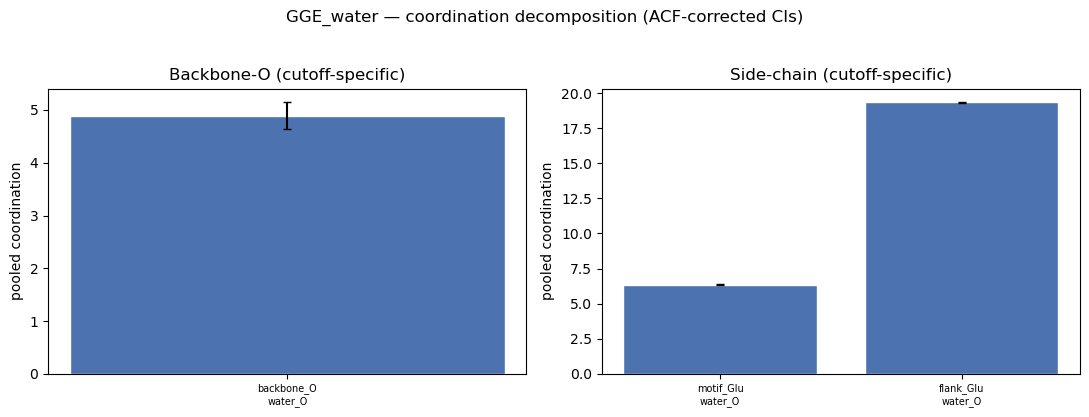

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, df, ttl in ((axes[0], bb_coord, 'Backbone-O'),
                    (axes[1], sc_coord, 'Side-chain')):
    d = df[df['structured_shell']] if 'structured_shell' in df else df
    if len(d) == 0:
        ax.text(0.5, 0.5, 'no structured shells', ha='center', va='center',
                transform=ax.transAxes, color='grey'); ax.set_title(ttl); continue
    x = np.arange(len(d))
    ax.bar(x, d['pooled_coord'], yerr=d['ci95'], capsize=3,
           color='#4c72b0', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r.reference}\n{r.partner}' for r in d.itertuples()],
                       rotation=0, fontsize=7)
    ax.set_ylabel('pooled coordination'); ax.set_title(f'{ttl} (cutoff-specific)')
fig.suptitle(f'{SYSTEM} — coordination decomposition (ACF-corrected CIs)', y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'coordination', 'coordination_decomposition.png'),
            dpi=200, bbox_inches='tight')
plt.show()


## §11 · E3.3 — Backbone hydrogen bonds (anomaly test)

**In:** per-start / pooled trajs.  **Out:** `hbonds/hbond_lifetimes.csv`, figure.

Backbone H-bonds ±3 residues around the motif; run-length lifetimes at 0.35 nm donor–acceptor.
Tier A → pooled. (Phase-3 10 ns context: GGE_reline had 1168 backbone H-bond events; not directly
comparable — different window and start ensemble.)


In [25]:
# Backbone H-bonds at FULL 1 ps resolution, PER START (two corrections from validation):
#   (1) stride=1 — §7b showed stride=10 aliases: ~87% of contact episodes discarded, median
#       inflated ~6.7x (KS D=0.843). H-bonds require full temporal resolution.
#   (2) per-start run-lengths — a joined-trajectory run-length would count a contact spanning a
#       start-boundary seam as one spurious episode. Each start is analysed independently and the
#       episode lists are concatenated.
# At 1 ps a persistent bond that rattles across the cutoff fragments into many short episodes,
# so these are CONTINUOUS threshold-crossing episode durations (comparative across solvents), not
# intermittent bond lifetimes. HBOND_BREAK_TOL=0 reproduces the carried continuous definition;
# >0 bridges brief sub-cutoff excursions toward an intermittent lifetime (cross-solvent choice).
region = set(range(max(0, motif_idx[0] - 3), motif_idx[-1] + 4))
DISCARD_FRAMES_FULL = DISCARD_FRAMES * ANALYSIS_STRIDE      # 20 ns at 1 ps = 20000 frames
HBOND_DIST_CUT  = 0.35                                       # donor-acceptor (workflow §3.3)
HBOND_BREAK_TOL = 0                                          # frames; 0 = continuous episodes

def _close_gaps(contact, tol):
    """Bridge internal False-runs of length <= tol (flanked by True) to tolerate brief breaks."""
    if tol <= 0:
        return contact
    c = contact.copy(); n = len(c); i = 0
    while i < n:
        if not c[i]:
            j = i
            while j < n and not c[j]:
                j += 1
            if 0 < i and j < n and (j - i) <= tol:      # internal short gap only
                c[i:j] = True
            i = j
        else:
            i += 1
    return c

def hbond_lifetimes_full(dcd, top_path, region_res_idx, discard_full,
                         dist_cut=HBOND_DIST_CUT, break_tol=HBOND_BREAK_TOL, backbone_only=True):
    """Continuous backbone H-bond episode durations (ps) for ONE start at 1 ps resolution.
    Baker-Hubbard identifies persistent bonds; each bond's donor-acceptor distance is run-lengthed
    under dist_cut (optionally bridging gaps <= break_tol). Returns (lifetimes, labels).
    backbone_only restricts to backbone N (donor) -> backbone O (acceptor), i.e. genuine
    backbone-backbone H-bonds; region membership alone would also admit sidechain carboxylate
    acceptors (N-H...OE) and intra-residue five-ring artifacts, which are out of §3.3 scope."""
    tr = md.load(dcd, top=top_path)[discard_full:]
    top = tr.topology
    prot = get_protein_residues(top)
    region = {a.index for r in prot if r.index in region_res_idx for a in r.atoms}
    if not region:
        del tr; return [], []
    bb = [(d, h, a) for (d, h, a) in md.baker_hubbard(tr, periodic=False)
          if d in region and a in region
          and (not backbone_only or (top.atom(d).name == 'N' and top.atom(a).name == 'O'))]
    lifetimes, labels = [], []
    for (d, h, a) in bb:
        contact = _close_gaps(md.compute_distances(tr, np.array([[d, a]]))[:, 0] < dist_cut, break_tol)
        runs, run = [], 0
        for v in contact:
            if v: run += 1
            elif run: runs.append(run); run = 0
        if run: runs.append(run)
        if runs:
            lifetimes.extend((np.array(runs) * SAVE_INTERVAL_PS).tolist())
            dr, ar = top.atom(d).residue, top.atom(a).residue
            labels.append(f'{dr.name}{dr.resSeq}:{top.atom(d).name}-{ar.name}{ar.resSeq}:{top.atom(a).name}')
    del tr
    return lifetimes, labels

per_start_hb, lifetimes, labels = [], [], []
for s in START_LABELS:
    lt, lab = hbond_lifetimes_full(RUNS[s]['dcd'], TOP_PATH, region, DISCARD_FRAMES_FULL)
    lifetimes += lt; labels += lab
    row = dict(start=s, n_episodes=len(lt), n_bonds=len(set(lab)),
               median_ps=round(float(np.median(lt)), 2) if lt else 0.0,
               mean_ps=round(float(np.mean(lt)), 2) if lt else 0.0)
    per_start_hb.append(row)
    print(f"  {s:<10} {row['n_episodes']:>6} episodes  median {row['median_ps']:>5} ps  {row['n_bonds']} bonds")

hb = dict(system=SYSTEM, resolution_ps=SAVE_INTERVAL_PS, break_tol_frames=HBOND_BREAK_TOL,
          n_events=len(lifetimes),
          median_ps=round(float(np.median(lifetimes)), 2) if lifetimes else 0.0,
          mean_ps=round(float(np.mean(lifetimes)), 2) if lifetimes else 0.0,
          p90_ps=round(float(np.percentile(lifetimes, 90)), 2) if lifetimes else 0.0,
          n_distinct_bonds=len(set(labels)))
pd.DataFrame(per_start_hb).to_csv(os.path.join(OUT_DIR, 'hbonds', 'per_start_hbond_summary.csv'), index=False)
pd.DataFrame([hb]).to_csv(os.path.join(OUT_DIR, 'hbonds', 'hbond_lifetimes.csv'), index=False)
print('\nPooled (1 ps, continuous episodes):', hb)
print('distinct bonds:', sorted(set(labels))[:12])


  compact     51849 episodes  median   2.0 ps  5 bonds
  extended    20630 episodes  median   3.0 ps  3 bonds
  mid         56055 episodes  median   2.0 ps  6 bonds
  open        18148 episodes  median   4.0 ps  3 bonds

Pooled (1 ps, continuous episodes): {'system': 'GGE_water', 'resolution_ps': 1.0, 'break_tol_frames': 0, 'n_events': 146682, 'median_ps': 2.0, 'mean_ps': 7.35, 'p90_ps': 15.0, 'n_distinct_bonds': 8}
distinct bonds: ['GLU3:N-GLU1:O', 'GLY4:N-GLU1:O', 'GLY5:N-GLU2:O', 'ILE7:N-GLY4:O', 'PHE9:N-GLU6:O', 'PHE9:N-GLY5:O', 'VAL8:N-GLY4:O', 'VAL8:N-GLY5:O']


In [26]:
# §7b — H-bond stride sensitivity (workflow open-Q1): stride=1 vs stride=10 on one start.
# H-bond lifetimes are the observable most likely to need full resolution; decide empirically.
sc_start = 'compact'
tr_full = md.load(RUNS[sc_start]['dcd'], top=TOP_PATH)[DISCARD_FRAMES * ANALYSIS_STRIDE:]
lt1, _  = compute_hbond_lifetimes(tr_full, region, prot_res, save_interval_ps=SAVE_INTERVAL_PS)
lt10, _ = compute_hbond_lifetimes(start_trajs[sc_start], region, prot_res, save_interval_ps=DT_PS)

from scipy.stats import ks_2samp
ks = ks_2samp(lt1, lt10) if (lt1 and lt10) else None
print(f'stride=1 : n={len(lt1)}  median={np.median(lt1) if lt1 else 0:.2f} ps')
print(f'stride=10: n={len(lt10)} median={np.median(lt10) if lt10 else 0:.2f} ps')
if ks: print(f'KS: D={ks.statistic:.3f}, p={ks.pvalue:.3g}  '
             f'→ {"distributions differ; short events aliased at 10 ps" if ks.pvalue < 0.05 else "consistent; stride=10 adequate for H-bonds"}')
pd.DataFrame([dict(start=sc_start, n_stride1=len(lt1), n_stride10=len(lt10),
                   median1=float(np.median(lt1)) if lt1 else 0,
                   median10=float(np.median(lt10)) if lt10 else 0,
                   ks_D=ks.statistic if ks else np.nan, ks_p=ks.pvalue if ks else np.nan)]
             ).to_csv(os.path.join(OUT_DIR, 'hbonds', 'hbond_stride_test.csv'), index=False)
del tr_full


stride=1 : n=64178  median=2.00 ps
stride=10: n=8901 median=20.00 ps
KS: D=0.870, p=0  → distributions differ; short events aliased at 10 ps


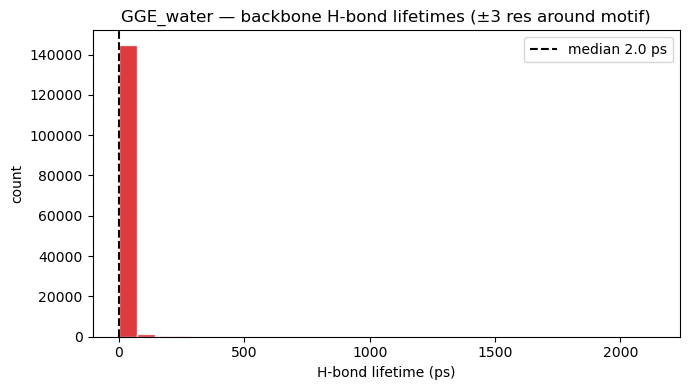

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
if lifetimes:
    ax.hist(lifetimes, bins=30, color='#d7191c', edgecolor='white', alpha=0.85)
    ax.axvline(np.median(lifetimes), ls='--', color='k',
               label=f'median {np.median(lifetimes):.1f} ps')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'no backbone H-bonds detected', ha='center', va='center',
            transform=ax.transAxes, color='grey')
ax.set_xlabel('H-bond lifetime (ps)'); ax.set_ylabel('count')
ax.set_title(f'{SYSTEM} — backbone H-bond lifetimes (±3 res around motif)')
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hbonds', 'hbond_lifetime_distributions.png'),
            dpi=200, bbox_inches='tight')
plt.show()


## §12 · E3.4 — System summary (closed vs contributed, per the three E3 questions)

**In:** all above + carried E2.x reference.  **Out:** `{SYSTEM}_summary.csv` (machine table),
`{SYSTEM}_summary.md` (readable record for cross-system collation), `{SYSTEM}_summary_figure.png`.

The summary is organised by the three E3 questions and, per system, states what it **closes** versus
what it only **contributes toward** (deferred to the cross-solvent stage). System-property flags drive
the tagging: whether this is the named E3.1 significance case (GGE_glyceline), whether the solvent can
test the E3.2 indirect-mechanism question directly (glyceline carries glycerol), and whether this is the
E3.3 anomaly system (YIY). The `.md` output persists the readable block that was previously print-only.


In [28]:
def carried(obs):
    if conv.get('pooled') is None: return (np.nan, np.nan)
    row = conv['pooled'][conv['pooled']['observable'].str.upper() == obs.upper()]
    if row.empty: return (np.nan, np.nan)
    return (float(row.iloc[0]['pooled_mean']), float(row.iloc[0]['ci95']))

sasa_m, sasa_ci = carried('SASA')
rg_m, rg_ci     = carried('Rg')

# H-bond provenance guard: the summary must carry the SAME quantity E3.3 computed — the
# full-resolution (1 ps) backbone H-bond result — never a stale stride-10 / mixed-scope hb.
assert hb.get('resolution_ps') == SAVE_INTERVAL_PS, (
    f"H-bond source is not {SAVE_INTERVAL_PS} ps (hb.resolution_ps={hb.get('resolution_ps')}). "
    "Re-run E3.3 (full-resolution backbone H-bonds) before building the summary.")

# System-property flags driving the closed/deferred tagging (Paper1 E3.1-E3.3 questions).
IS_SIGNIFICANCE_TESTCASE = (SYSTEM == 'GGE_glyceline')   # named E3.1 test: Phase-3 corrected ES 1.18
TESTS_INDIRECT_DIRECTLY  = (SOLVENT == 'glyceline')      # glycerol present -> glycerol-sidechain test
IS_ANOMALY_SYSTEM        = (PEP == 'YIY')                # E3.3 YIY reline 1433-event anomaly
BOTH_ROBUST = (CARRIED_VERDICT['SASA'] == 'robust' and CARRIED_VERDICT['Rg'] == 'robust')

summary = dict(
    system=SYSTEM, tier=TIER, n_starts=len(START_LABELS), starts=';'.join(START_LABELS),
    character=CARRIED_VERDICT['character'],
    sasa_pooled_nm2=sasa_m, sasa_ci95=sasa_ci, sasa_verdict=CARRIED_VERDICT['SASA'],
    rg_pooled_nm=rg_m, rg_ci95=rg_ci, rg_verdict=CARRIED_VERDICT['Rg'],
    hbond_events=hb['n_events'], hbond_median_ps=hb['median_ps'],
    hbond_resolution_ps=hb['resolution_ps'], hbond_break_tol_frames=hb['break_tol_frames'],
    hbond_n_backbone_bonds=hb['n_distinct_bonds'],
    n_structured_backbone_pairs=int(bb_coord['structured_shell'].sum()) if len(bb_coord) else 0,
    n_structured_sidechain_pairs=int(sc_coord['structured_shell'].sum()) if len(sc_coord) else 0,
)
pd.DataFrame([summary]).to_csv(os.path.join(OUT_DIR, f'{SYSTEM}_summary.csv'), index=False)

def _tbl(df, cols):
    return df[cols].to_string(index=False) if len(df) else '(none)'

closed, deferred, L = [], [], []
L += [f'# E3.x system summary - {SYSTEM}', '',
      f'Tier {TIER} | {len(START_LABELS)}-start ({", ".join(START_LABELS)}) | {CARRIED_VERDICT["character"]}',
      f'Peptide {PEP} | solvent {SOLVENT}', '']

# --- E3.1 -----------------------------------------------------------------
if TIER == 'D' and basin_sasa is not None:
    L += ['## E3.1 - Replicate-aware SASA & backbone coordination',
          '- SASA is the DIVERGENT observable (multi-basin) - reported as a diverse-start ENSEMBLE,',
          '  NOT an equilibrium mean. Grouped-start basin means (corrected CIs):',
          f'  - HIGH basin ({basin_sasa["high_starts"]}): {basin_sasa["high_mean"]} +/- {basin_sasa["high_ci95"]} nm2',
          f'  - LOW basin  ({basin_sasa["low_starts"]}): {basin_sasa["low_mean"]} +/- {basin_sasa["low_ci95"]} nm2',
          f'  - Pooled ensemble (NOT equilibrium): {basin_sasa["pooled_mean"]} +/- {basin_sasa["pooled_ci95"]} nm2',
          f'  - E2.2 sidecar cross-check: {basin_sasa["sidecar_sasa"]} (delta {basin_sasa["sidecar_delta"]})',
          f'- Rg (carried E2.2 pooled): {rg_m} +/- {rg_ci} nm  [{CARRIED_VERDICT["Rg"]}]',
          f'- Convergence character: {CARRIED_VERDICT["character"]}',
          '- Backbone-O coordination (pooled; local, basin-independent):',
          '```', _tbl(bb_coord, ['partner', 'cutoff_nm', 'pooled_coord', 'ci95']), '```',
          '- CONTRIBUTES: this water system supplies the aqueous SASA baseline, but as a multi-basin '
          'ensemble the equilibrium mean is unresolved; true basin populations need enhanced sampling.']
    deferred.append('E3.1 SASA equilibrium mean (multi-basin; enhanced sampling -> Paper 2)')
else:
    L += ['## E3.1 - Replicate-aware SASA & backbone coordination',
          f'- SASA (carried E2.2 pooled): {sasa_m} +/- {sasa_ci} nm2  [{CARRIED_VERDICT["SASA"]}]',
          f'- Rg   (carried E2.2 pooled): {rg_m} +/- {rg_ci} nm  [{CARRIED_VERDICT["Rg"]}]',
          f'- Convergence character: {CARRIED_VERDICT["character"]}',
          '- Backbone-O coordination (pair-specific cutoffs, ACF-corrected CIs):',
          '```', _tbl(bb_coord, ['partner', 'cutoff_nm', 'pooled_coord', 'ci95']), '```']
    if IS_SIGNIFICANCE_TESTCASE:
        L += ['- CLOSES: named E3.1 significance test case (Phase-3 corrected ES 1.18); the verdict '
              'against corrected CIs is the load-bearing E3.1 result for the campaign.']
        closed.append('E3.1 significance (named test case)')
    else:
        L += [f'- Replicate significance for THIS system: '
              f'{"achieved (both observables robust)" if BOTH_ROBUST else "see convergence character"}. '
              'The named E3.1 test case (GGE_glyceline, corrected ES 1.18) is a separate system; its '
              'significance verdict is deferred there.']
        if BOTH_ROBUST: closed.append('E3.1 convergence for this system (robust)')
        deferred.append('E3.1 headline significance (GGE_glyceline ES 1.18)')
L += ['']

# --- E3.2 -----------------------------------------------------------------
L += ['## E3.2 - Side-chain coordination (indirect-restructuring test)',
      '- Side-chain coordination (pair-specific cutoffs, ACF-corrected CIs):',
      '```', _tbl(sc_coord, ['reference','partner','cutoff_nm','pooled_coord','ci95']), '```']
if TESTS_INDIRECT_DIRECTLY:
    L += ['- CLOSES (in part): glyceline system - glycerol-sidechain coordination is the direct test '
          'of the indirect hypothesis. Substantial glycerol-Tyr/Cys/Glu contact challenges purely-'
          'indirect; absence supports it. Read against the water baseline.']
    closed.append('E3.2 glycerol-sidechain contact (this solvent)')
else:
    _base = ('urea direct-contact baseline (urea coordinates backbone AND carboxylate here)'
             if SOLVENT == 'reline' else 'aqueous baseline that rules out a peptide-intrinsic explanation')
    L += [f'- CONTRIBUTES (baseline): {SOLVENT} carries no glycerol, so it cannot test the '
          f'glycerol-sidechain question directly. It supplies the {_base}. The decisive glycerol '
          'comparison is deferred to the glyceline systems + water baseline.']
    deferred.append('E3.2 indirect-mechanism adjudication (glyceline + water)')
L += ['- Observation: motif vs flanking carboxylate coordinate near-uniformly per O (uniform acidic '
      'behaviour rather than local context) - a hypothesis the other systems test.', '']

# --- E3.3 -----------------------------------------------------------------
L += ['## E3.3 - Backbone hydrogen bonds (anomaly test)',
      f'- {hb["n_distinct_bonds"]} backbone i->i-3 turns; {hb["resolution_ps"]:.0f} ps resolution, '
      f'{hb["n_events"]} continuous episodes, median {hb["median_ps"]} ps (break_tol={hb["break_tol_frames"]}).']
if IS_ANOMALY_SYSTEM:
    L += ['- CLOSES (in part): YIY is the anomaly system (Phase-3: 1433 reline events vs 0 in '
          'water/glyceline). Per-start consistency of the anomaly is the load-bearing E3.3 result; '
          'a replicate-dependent anomaly changes the mechanistic reading.']
    closed.append('E3.3 YIY H-bond anomaly (per-start consistency)')
else:
    L += ['- CONTRIBUTES: the H-bond anomaly is YIY reline; this system validated the H-bond machinery '
          'and established the 1 ps resolution requirement (stride=10 aliases ~87% of episodes). '
          'Anomaly adjudication deferred to the YIY systems.']
    deferred.append('E3.3 anomaly adjudication (YIY systems)')
L += ['- Note: the continuous-episode median is largely blind to slow exchange; the persistence '
      'definition (continuous vs intermittent/ACF) is fixed at the cross-solvent stage.', '']

# --- carried caveats ------------------------------------------------------
L += ['## Carried caveats',
      '- Chloride: no structured shell (backbone or side-chain) - reportable null.']
_chol = bb_coord[(bb_coord['reference'] == 'backbone_O') & (bb_coord['partner'] == 'choline_N')] \
        if len(bb_coord) else pd.DataFrame()
if len(_chol) and bool(_chol['structured_shell'].any()):
    L += ['- Choline-N -> backbone-O registers a weak feature absent in the E3.0 preliminary and '
          'carrying the highest cutoff-sensitivity - treated as a shoulder, not an established shell.']
L += ['- Side-chain cutoffs are novel (no E3.0 anchor); low reference-atom count -> convergence caveat.', '']

# --- ledger ---------------------------------------------------------------
L += ['## Question ledger', 'CLOSED by this system:']
L += [f'  - {c}' for c in closed] if closed else ['  - (none - validation/contribution system)']
L += ['CONTRIBUTES toward (deferred to cross-solvent stage):']
L += [f'  - {d}' for d in deferred] if deferred else ['  - (none)']

summary_text = '\n'.join(L)
with open(os.path.join(OUT_DIR, f'{SYSTEM}_summary.md'), 'w') as f:
    f.write(summary_text + '\n')
print(summary_text)


# E3.x system summary - GGE_water

Tier D | 4-start (compact, extended, mid, open) | multi-basin (2+2 SASA split)
Peptide GGE | solvent water

## E3.1 - Replicate-aware SASA & backbone coordination
- SASA is the DIVERGENT observable (multi-basin) - reported as a diverse-start ENSEMBLE,
  NOT an equilibrium mean. Grouped-start basin means (corrected CIs):
  - HIGH basin (extended;open): 2.8443 +/- 0.0617 nm2
  - LOW basin  (compact;mid): 2.3357 +/- 0.0882 nm2
  - Pooled ensemble (NOT equilibrium): 2.59 +/- 0.0656 nm2
  - E2.2 sidecar cross-check: 2.59 (delta 0.0)
- Rg (carried E2.2 pooled): 0.704 +/- 0.0176 nm  [dominated]
- Convergence character: multi-basin (2+2 SASA split)
- Backbone-O coordination (pooled; local, basin-independent):
```
partner  cutoff_nm  pooled_coord  ci95
water_O      0.333        4.8929 0.255
```
- CONTRIBUTES: this water system supplies the aqueous SASA baseline, but as a multi-basin ensemble the equilibrium mean is unresolved; true basin populations need enhan

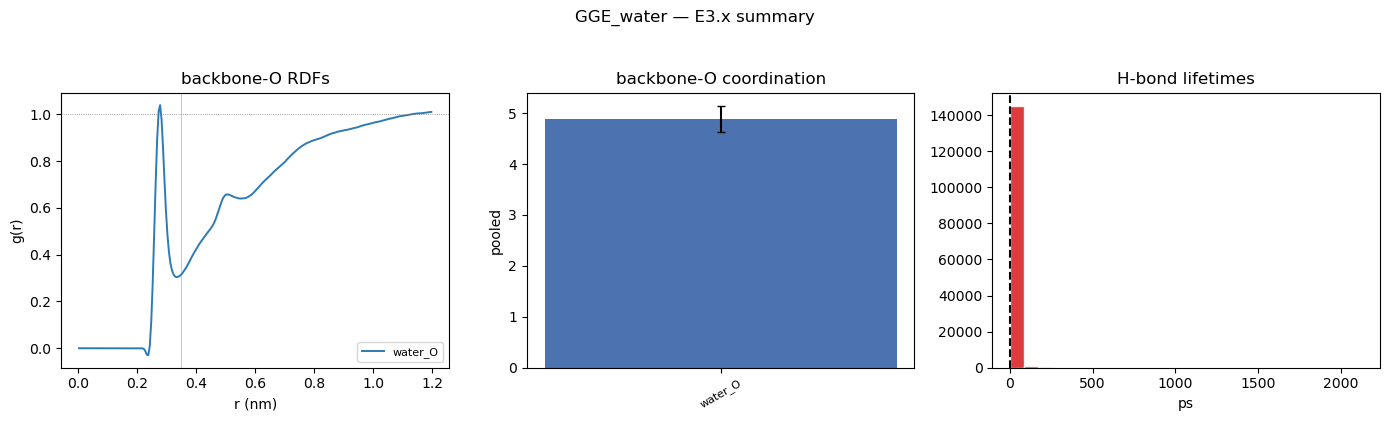

Outputs written under: /Users/rossgibson/des-peptide-study/extension/analysis/E3x/GGE_water


In [29]:
# Summary figure: RDF (backbone water + urea-O), coordination decomposition, H-bond dist
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
_fig_partners = [('water_O', '#2c7bb6')] + ([(DES_O_PARTNER, '#d7191c')] if DES_O_PARTNER else [])
for pk, c in _fig_partners:
    if ('backbone_O', pk) in rdf_curves:
        r, g, gs, rmin = rdf_curves[('backbone_O', pk)]
        if g is not None:
            axes[0].plot(r, gs, lw=1.4, color=c, label=pk)
            if rmin: axes[0].axvline(rmin, ls='--', lw=0.9, color=c, alpha=0.7)
axes[0].axhline(1, ls=':', lw=0.6, color='grey'); axes[0].axvline(0.35, ls='-', lw=0.6, color='grey', alpha=0.5)
axes[0].set_title('backbone-O RDFs'); axes[0].set_xlabel('r (nm)'); axes[0].set_ylabel('g(r)'); axes[0].legend(fontsize=8)

d = bb_coord[bb_coord['structured_shell']] if len(bb_coord) else bb_coord
if len(d):
    axes[1].bar(np.arange(len(d)), d['pooled_coord'], yerr=d['ci95'], capsize=3, color='#4c72b0')
    axes[1].set_xticks(np.arange(len(d))); axes[1].set_xticklabels(d['partner'], rotation=30, fontsize=8)
axes[1].set_title('backbone-O coordination'); axes[1].set_ylabel('pooled')

if lifetimes:
    axes[2].hist(lifetimes, bins=25, color='#d7191c', edgecolor='white', alpha=0.85)
    axes[2].axvline(np.median(lifetimes), ls='--', color='k')
axes[2].set_title('H-bond lifetimes'); axes[2].set_xlabel('ps')
fig.suptitle(f'{SYSTEM} — E3.x summary', y=1.04)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{SYSTEM}_summary_figure.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Outputs written under:', OUT_DIR)


## §13 — Template-readiness checklist

Validated on GGE_reline (tier A). To advance to systems 2–9, **only the following change**:

1. **§1 knob:** `SYSTEM`, `TIER`.
2. **§3 `SIDECHAIN_SPEC[PEP]`:** complete the CME/YIY entries (placeholders present). CME has four
   heteroatom reference types (Cys SG, Met SD, Glu OE); YIY has two Tyr OH.
3. **Tier branches (not yet exercised here):**
   - **B (YIY):** add per-start H-bond reporting (assess the reline anomaly across the 4 starts);
     carry the non-ergodic-backbone caveat on Rg-conditioned quantities; SASA-derived quantities
     remain pooled. The SASA–Rg decoupling is itself a reportable finding.
   - **C (CME_reline):** run every analysis twice — full pool and consensus-without-extended — and
     report sensitivity to including the trapped start.
   - **D (CME_glyceline, GGE_water):** define a SASA/Rg basin boundary, split trajectories, compute
     per-basin RDFs/coordination; report distributions, not a single pooled value. (This is where the
     tier-A "carried SASA/Rg time series" hook becomes load-bearing — tier A skips it.)
4. **Stride:** before adopting stride=10 globally for coordination, run the §6b water spot-check on a
   water system (handoff §4 caveat).

Unresolved-by-design flags to keep visible: floored τ_int rows (N_eff=N, not a measurement);
side-chain RDF statistical power at low n_ref; the DCD backup action (E2.x §6) — E3.x reads the full
trajectories, so resolve backup before running the campaign end-to-end.
